File ZIP berhasil diekstrak

===== DATASET AWAL =====
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4

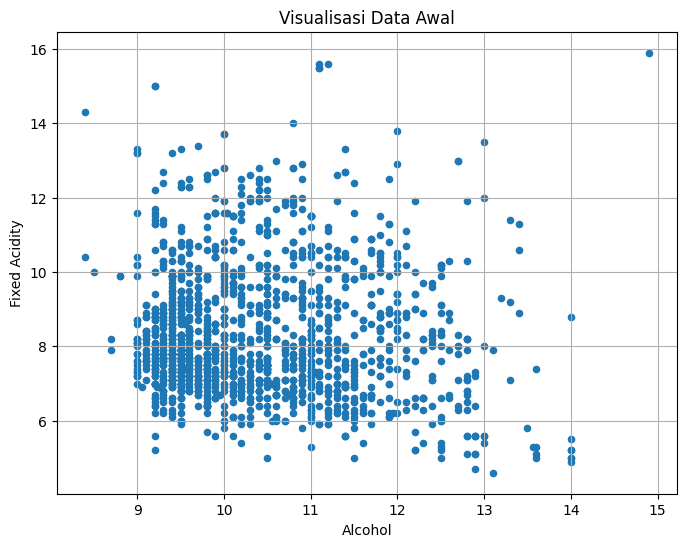


===== MEMBUAT DENDROGRAM =====


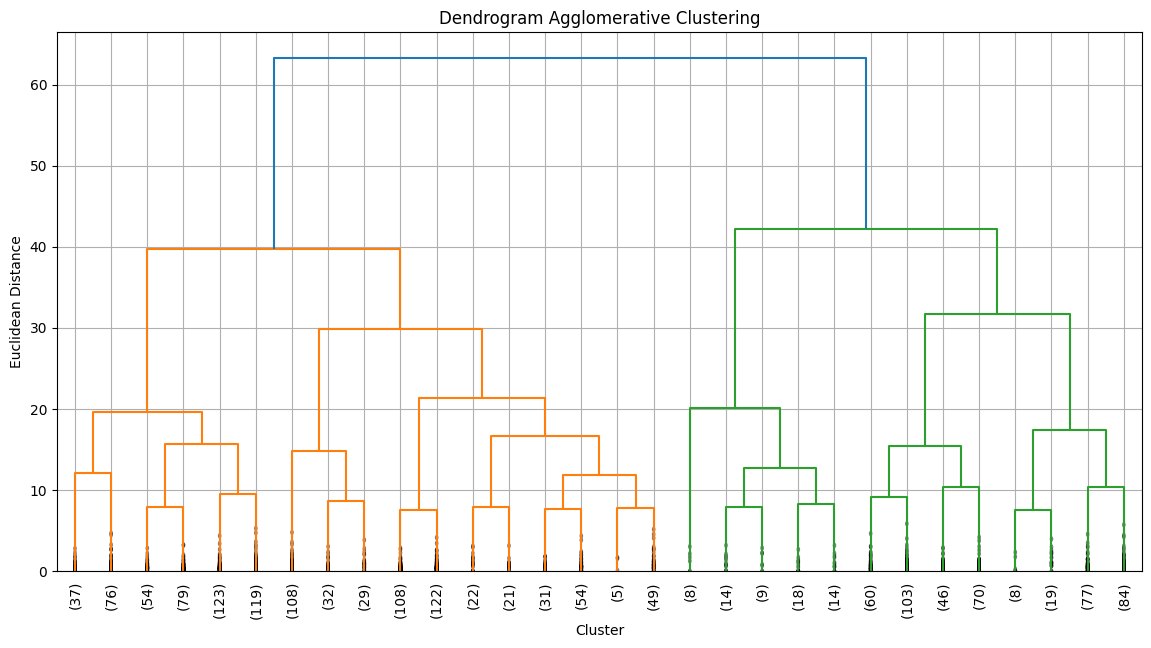


===== SILHOUETTE SCORE =====
K = 2 | Silhouette Score = 0.29458697477307527
K = 3 | Silhouette Score = 0.29838994368034794
K = 4 | Silhouette Score = 0.18582707450810163
K = 5 | Silhouette Score = 0.19810342553387364
K = 6 | Silhouette Score = 0.2023427551350648
K = 7 | Silhouette Score = 0.1746881143222176
K = 8 | Silhouette Score = 0.17828236025446995
K = 9 | Silhouette Score = 0.17448647010835813
K = 10 | Silhouette Score = 0.18075786010512082


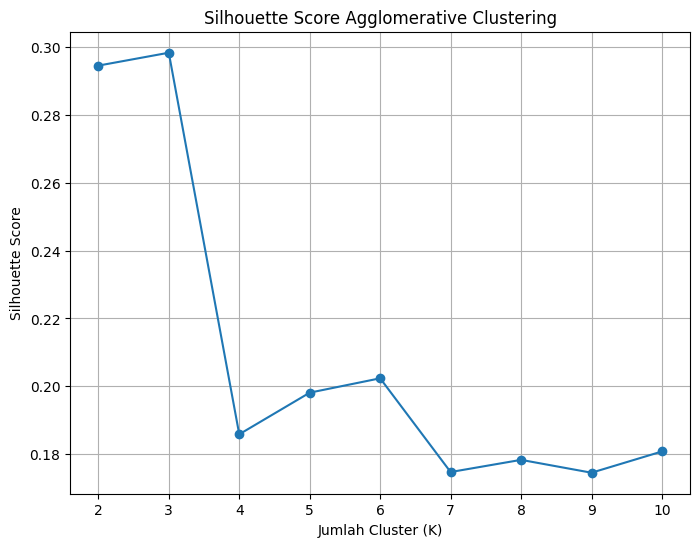


K terbaik = 3

===== HASIL CLUSTER =====
   alcohol  fixed acidity  volatile acidity  Cluster
0      9.4            7.4              0.70        0
1      9.8            7.8              0.88        0
2      9.8            7.8              0.76        0
3      9.8           11.2              0.28        1
4      9.4            7.4              0.70        0


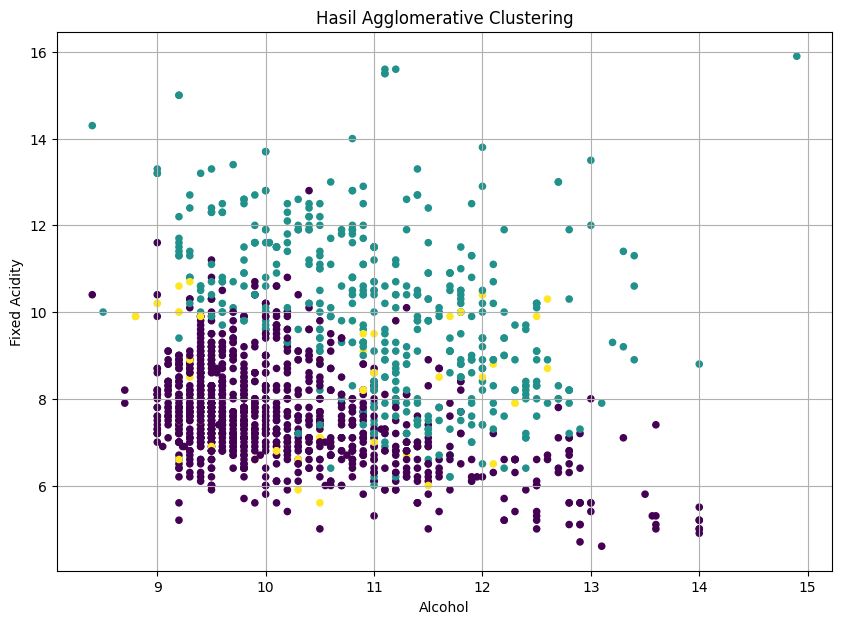


===== JUMLAH DATA PER CLUSTER =====
Cluster
0    1069
1     467
2      63
Name: count, dtype: int64

===== RATA-RATA TIAP CLUSTER =====
         fixed acidity  volatile acidity  citric acid  residual sugar  \
Cluster                                                                 
0             7.629280          0.594855     0.180514        2.268990   
1             9.917773          0.380557     0.464069        2.451178   
2             8.187302          0.481984     0.374603        7.766667   

           alcohol  
Cluster             
0        10.139367  
1        11.066096  
2        10.468254  

===== INTERPRETASI =====
Nilai silhouette score terbaik = 0.2984
Struktur cluster lemah

Hasil clustering berhasil disimpan

Program selesai dijalankan


In [4]:
# ============================================================
# IMPLEMENTASI AGGLOMERATIVE HIERARCHICAL CLUSTERING
# DATASET : WINE QUALITY
# + DENDROGRAM
# + SILHOUETTE SCORE
# + VISUALISASI CLUSTER
# ============================================================

# ============================================================
# IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from zipfile import ZipFile

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

# ============================================================
# EXTRACT FILE ZIP
# ============================================================

zip_path = "wine+quality.zip"

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

print("File ZIP berhasil diekstrak")

# ============================================================
# MEMBACA DATASET
# ============================================================

# gunakan salah satu:
# winequality-red.csv
# winequality-white.csv

DF = pd.read_csv(
    "winequality-red.csv",
    sep=';'
)

print("\n===== DATASET AWAL =====")
print(DF.head())

# ============================================================
# INFORMASI DATASET
# ============================================================

print("\n===== INFORMASI DATASET =====")
print(DF.info())

# ============================================================
# CEK MISSING VALUE
# ============================================================

print("\n===== MISSING VALUE =====")
print(DF.isnull().sum())

# ============================================================
# MEMILIH FITUR
# ============================================================

FITUR = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'alcohol'
]

X = DF[FITUR]

print("\n===== FITUR YANG DIGUNAKAN =====")
print(X.head())

# ============================================================
# NORMALISASI DATA
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nData berhasil dinormalisasi")

# ============================================================
# VISUALISASI DATA AWAL
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    X['alcohol'],
    X['fixed acidity'],
    s=20
)

plt.title('Visualisasi Data Awal')
plt.xlabel('Alcohol')
plt.ylabel('Fixed Acidity')

plt.grid(True)

plt.show()

# ============================================================
# MEMBUAT DENDROGRAM
# ============================================================

print("\n===== MEMBUAT DENDROGRAM =====")

# linkage matrix
linked = linkage(
    X_scaled,
    method='ward'
)

plt.figure(figsize=(14,7))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.title('Dendrogram Agglomerative Clustering')
plt.xlabel('Cluster')
plt.ylabel('Euclidean Distance')

plt.grid(True)

plt.show()

# ============================================================
# MENCARI K TERBAIK DENGAN SILHOUETTE SCORE
# ============================================================

print("\n===== SILHOUETTE SCORE =====")

silhouette_scores = []

K_range = range(2, 11)

for k in K_range:

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f"K = {k} | Silhouette Score = {score}")

# ============================================================
# VISUALISASI SILHOUETTE SCORE
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(
    K_range,
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score Agglomerative Clustering')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')

plt.grid(True)

plt.show()

# ============================================================
# MENENTUKAN K TERBAIK
# ============================================================

best_k = K_range[
    np.argmax(silhouette_scores)
]

print("\nK terbaik =", best_k)

# ============================================================
# MODEL FINAL AGGLOMERATIVE
# ============================================================

model_final = AgglomerativeClustering(
    n_clusters=best_k,
    linkage='ward'
)

labels = model_final.fit_predict(X_scaled)

# ============================================================
# MENAMBAHKAN LABEL CLUSTER
# ============================================================

DF['Cluster'] = labels

print("\n===== HASIL CLUSTER =====")
print(
    DF[
        [
            'alcohol',
            'fixed acidity',
            'volatile acidity',
            'Cluster'
        ]
    ].head()
)

# ============================================================
# VISUALISASI HASIL CLUSTERING
# ============================================================

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    DF['alcohol'],
    DF['fixed acidity'],
    c=labels,
    s=20
)

plt.title('Hasil Agglomerative Clustering')
plt.xlabel('Alcohol')
plt.ylabel('Fixed Acidity')

plt.grid(True)

plt.show()

# ============================================================
# JUMLAH DATA PER CLUSTER
# ============================================================

print("\n===== JUMLAH DATA PER CLUSTER =====")

print(
    DF['Cluster'].value_counts()
)

# ============================================================
# RATA-RATA TIAP CLUSTER
# ============================================================

print("\n===== RATA-RATA TIAP CLUSTER =====")

print(
    DF.groupby('Cluster')[FITUR].mean()
)

# ============================================================
# INTERPRETASI SILHOUETTE SCORE
# ============================================================

nilai_terbaik = max(silhouette_scores)

print("\n===== INTERPRETASI =====")

print(f"Nilai silhouette score terbaik = {nilai_terbaik:.4f}")

if nilai_terbaik >= 0.7:

    print("Struktur cluster sangat baik dan terpisah jelas")

elif nilai_terbaik >= 0.5:

    print("Struktur cluster cukup baik")

elif nilai_terbaik >= 0.25:

    print("Struktur cluster lemah")

elif nilai_terbaik >= 0:

    print("Cluster overlap")

else:

    print("Terjadi kesalahan clustering")

# ============================================================
# SIMPAN HASIL
# ============================================================

DF.to_csv(
    "hasil_agglomerative_clustering_wine.csv",
    index=False
)

print("\nHasil clustering berhasil disimpan")

# ============================================================
# SELESAI
# ============================================================

print("\nProgram selesai dijalankan")